# Link Prediction: GCN for "Will These Nodes Connect?" (PyTorch Geometric)

This is the third and final fundamental GNN task, alongside the earlier two notebooks:

| Notebook | Predicts | Granularity |
|---|---|---|
| `gnn_node_classification.ipynb` | a label **per node** | node-level |
| `gnn_graph_classification.ipynb` | a label **per whole graph** | graph-level |
| **this notebook** | whether an **edge exists between two nodes** | edge-level |

Dataset: the same **Cora** citation graph as the node-classification notebook (2,708 papers, 10,556 citation edges) — reused deliberately so the only thing that changes is the *task*, not the data. Instead of "what subject is this paper?" we now ask **"does paper A cite paper B?"** — hide some real citation edges, mix in fake (non-existent) ones, and see if the model can tell them apart using only the *remaining* visible graph structure.

This is exactly the "Knowledge Graph -> question answering" and "Financial Fraud -> transaction ring" row from the use-case table: predicting a *relationship*, not a node's identity or a graph's global property.

Same overall pipeline as before:
1. Get the data
2. Profile the data
3. Prepare the graph for link prediction (split *edges*, not nodes, into train/val/test + negative sampling)
4. Build the model: GCN encoder -> dot-product edge decoder
5. Loss function & optimizer
6. Train, tracking train loss and validation ROC-AUC each epoch
7. Final evaluation on the held-out test edges
8. Inference: score specific node pairs, and recommend new likely citations for a paper
9. Save the model


## 0. Install & Import Libraries

In [1]:
# !pip install torch torch_geometric scikit-learn matplotlib --quiet

import random
from tqdm.auto import tqdm
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.datasets import Planetoid
import torch_geometric.transforms as T
from torch_geometric.nn import GCNConv
from torch_geometric.utils import negative_sampling

from sklearn.metrics import roc_auc_score, average_precision_score

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


## 1. Get the Data

Same Cora load as the node-classification notebook. This time we'll deliberately ignore the node labels (`data.y`, the subject categories) — link prediction here only cares about the graph's connectivity and the node features, not what class each paper belongs to.


In [2]:
dataset = Planetoid(root="./data/Cora", name="Cora")
data = dataset[0]

print("Graph:", data)
print("Number of nodes (papers):   ", data.num_nodes)
print("Number of edges (citations):", data.num_edges)
print("Node feature dimensionality:", dataset.num_node_features)


Graph: Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])
Number of nodes (papers):    2708
Number of edges (citations): 10556
Node feature dimensionality: 1433


## 2. Randomly Profile the Data

We already profiled class balance and node degree in the node-classification notebook — here the thing worth double-checking is **edge density**, since link prediction's difficulty depends heavily on it: with only ~10.5k real edges out of ~2708*2707/2 ≈ 3.7M possible node pairs, the graph is extremely sparse (~0.3%), so a trivial "always predict no edge" baseline would already be ~99.7% accurate on raw accuracy — which is exactly why link prediction is evaluated with **ROC-AUC / average precision** on a balanced sample of real vs. fake edges, not raw accuracy.


In [3]:
num_nodes = data.num_nodes
num_possible_pairs = num_nodes * (num_nodes - 1) / 2
num_real_edges = data.num_edges / 2  # data.edge_index stores each undirected edge twice

print(f"Real (undirected) edges: {int(num_real_edges):,}")
print(f"Possible node pairs:     {int(num_possible_pairs):,}")
print(f"Edge density:            {num_real_edges / num_possible_pairs:.4%}")


Real (undirected) edges: 5,278
Possible node pairs:     3,665,278
Edge density:            0.1440%


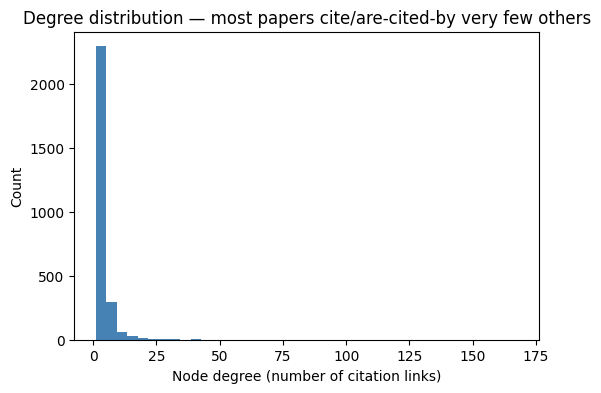

In [4]:
from torch_geometric.utils import degree

node_degrees = degree(data.edge_index[0], num_nodes=data.num_nodes).numpy()

plt.figure(figsize=(6, 4))
plt.hist(node_degrees, bins=40, color="steelblue")
plt.xlabel("Node degree (number of citation links)")
plt.ylabel("Count")
plt.title("Degree distribution — most papers cite/are-cited-by very few others")
plt.show()


## 3. Prepare the Graph for Link Prediction

This step looks different from the other two notebooks, because link prediction splits **edges**, not nodes:

- `RandomLinkSplit` holds out a fraction of the real edges for validation/test, leaving the rest as the "message-passing" graph the GCN can see and propagate over.
- For every real ("positive") edge in a split, it also needs a **fake ("negative") edge** — a node pair that is *not* connected — so the model has something to contrast against. Val/test negatives are sampled once and fixed (so evaluation is reproducible); train negatives are freshly re-sampled every epoch (see Section 6) so the model doesn't just memorize one fixed set of fake pairs.
- `is_undirected=True` matches Cora's citation graph being treated as undirected here (if A cites B, we care about the A-B link existing, not the direction).


In [5]:
transform = T.RandomLinkSplit(
    num_val=0.1,             # 10% of edges held out for validation
    num_test=0.1,            # 10% of edges held out for test
    is_undirected=True,
    add_negative_train_samples=False,  # we'll sample fresh negatives every epoch instead
)
train_data, val_data, test_data = transform(data)

print("Train split:", train_data)
print("Val split:  ", val_data)
print("Test split: ", test_data)


Train split: Data(x=[2708, 1433], edge_index=[2, 8448], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708], edge_label=[4224], edge_label_index=[2, 4224])
Val split:   Data(x=[2708, 1433], edge_index=[2, 8448], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708], edge_label=[1054], edge_label_index=[2, 1054])
Test split:  Data(x=[2708, 1433], edge_index=[2, 9502], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708], edge_label=[1054], edge_label_index=[2, 1054])


Each split has two edge-related fields with different jobs:
- `edge_index`: the edges the GCN is allowed to **message-pass over** (i.e. what the model can "see" when building node embeddings). For train, this is ~80% of real edges. For val/test, it's train + val edges respectively — the model always sees *more* of the graph at eval time, it just doesn't get to see the *specific* held-out edges it's being tested on.
- `edge_label_index` + `edge_label`: the specific node pairs to **score and classify** as edge/no-edge (1s = real held-out edges, 0s = sampled negative pairs), and their ground-truth labels.


## 4. Split into Train / Validation / Test

Already done above by `RandomLinkSplit` in one step — for link prediction, "the split" *is* the data-preparation step, since building the negative samples and the message-passing subgraphs for each split all happens together. No separate step needed here.


In [6]:
print(f"Train supervision edges (positives only): {train_data.edge_label_index.size(1)}")
print(f"Val supervision edges (pos + neg):           {val_data.edge_label_index.size(1)}")
print(f"Test supervision edges (pos + neg):          {test_data.edge_label_index.size(1)}")

train_data = train_data.to(device)
val_data = val_data.to(device)
test_data = test_data.to(device)


Train supervision edges (positives only): 4224
Val supervision edges (pos + neg):           1054
Test supervision edges (pos + neg):          1054


## 5. Build the Model: GCN Encoder + Dot-Product Decoder

This is a two-part model, the standard "graph autoencoder" shape for link prediction:
- **Encoder** (`GCNConv` x2): same building block as the other notebooks — turns each node's features + neighborhood into a dense embedding vector. No pooling here, since we need a vector *per node*, not per graph.
- **Decoder**: instead of a `Linear` classifier head, link prediction uses a **dot product** between two node embeddings as the "compatibility score" for that pair — the graph-ML equivalent of a recommender system scoring a (user, item) pair by the dot product of their embeddings. High dot product = the model thinks these two nodes' embeddings point in a similar direction = likely connected.


In [7]:
class GCNLinkPredictor(nn.Module):
    def __init__(self, in_features, hidden_dim, out_dim):
        super().__init__()
        self.conv1 = GCNConv(in_features, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, out_dim)

    def encode(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        z = self.conv2(x, edge_index)   # (num_nodes, out_dim) node embeddings
        return z

    def decode(self, z, edge_label_index):
        src, dst = edge_label_index
        return (z[src] * z[dst]).sum(dim=-1)   # dot product -> raw score (logit)


In [8]:
model = GCNLinkPredictor(
    in_features=dataset.num_node_features,
    hidden_dim=128,
    out_dim=64,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")


Total params: 191,808
Trainable params: 191,808


## 6. Loss Function & Optimizer

`BCEWithLogitsLoss` treats this as **binary classification per edge** (1 = real edge, 0 = fake pair) — the natural loss once the decoder's dot product is treated as a logit.


In [9]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)


## 7. Training Loop

Full-batch again (one graph), same as the node-classification notebook — but each epoch now also **re-samples fresh negative edges** before computing the loss, via `negative_sampling`. This means the model never sees the exact same set of "fake" pairs twice, which prevents it from overfitting to one arbitrary set of negatives instead of learning a real notion of "connectedness."


In [10]:
def train_one_epoch(model, train_data, optimizer, criterion):
    model.train()
    optimizer.zero_grad()

    z = model.encode(train_data.x, train_data.edge_index)

    # Fresh negative edges every epoch, matched in count to the positive supervision edges.
    neg_edge_index = negative_sampling(
        edge_index=train_data.edge_index,
        num_nodes=train_data.num_nodes,
        num_neg_samples=train_data.edge_label_index.size(1),
    )

    edge_label_index = torch.cat([train_data.edge_label_index, neg_edge_index], dim=1)
    edge_label = torch.cat([
        train_data.edge_label,
        torch.zeros(neg_edge_index.size(1), device=train_data.x.device),
    ])

    logits = model.decode(z, edge_label_index)
    loss = criterion(logits, edge_label)
    loss.backward()
    optimizer.step()

    return loss.item()


In [11]:
@torch.no_grad()
def evaluate(model, eval_data):
    model.eval()
    z = model.encode(eval_data.x, eval_data.edge_index)
    logits = model.decode(z, eval_data.edge_label_index)
    probs = torch.sigmoid(logits).cpu().numpy()
    labels = eval_data.edge_label.cpu().numpy()

    auc = roc_auc_score(labels, probs)
    ap = average_precision_score(labels, probs)
    return auc, ap


In [12]:
NUM_EPOCHS = 100

history = []

progress_bar = tqdm(range(1, NUM_EPOCHS + 1), desc="Epochs")
for epoch in progress_bar:
    train_loss = train_one_epoch(model, train_data, optimizer, criterion)
    val_auc, val_ap = evaluate(model, val_data)

    history.append({"epoch": epoch, "train_loss": train_loss, "val_auc": val_auc, "val_ap": val_ap})
    progress_bar.set_postfix(train_loss=train_loss, val_auc=val_auc)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Val AUC: {val_auc:.4f} | Val AP: {val_ap:.4f}")


Epochs:   0%|          | 0/100 [00:00<?, ?it/s]

Epochs:   0%|          | 0/100 [00:00<?, ?it/s, train_loss=0.665, val_auc=0.73]

Epochs:   1%|          | 1/100 [00:00<00:23,  4.23it/s, train_loss=0.665, val_auc=0.73]

Epochs:   1%|          | 1/100 [00:00<00:23,  4.23it/s, train_loss=1.71, val_auc=0.749]

Epochs:   2%|▏         | 2/100 [00:00<00:16,  5.90it/s, train_loss=1.71, val_auc=0.749]

...

Epochs:  98%|█████████▊| 98/100 [00:07<00:00, 13.44it/s, train_loss=0.407, val_auc=0.897]

Epochs:  98%|█████████▊| 98/100 [00:07<00:00, 13.44it/s, train_loss=0.405, val_auc=0.896]

Epochs: 100%|██████████| 100/100 [00:07<00:00, 13.37it/s, train_loss=0.405, val_auc=0.896]

Epochs: 100%|██████████| 100/100 [00:07<00:00, 12.50it/s, train_loss=0.405, val_auc=0.896]

Epoch 100/100 | Train Loss: 0.4046 | Val AUC: 0.8963 | Val AP: 0.9046


## 7a. Plot Training Curves

No "accuracy" here (raw accuracy would be misleadingly high on such a sparse graph, as discussed in Section 2) — **ROC-AUC** and **average precision** are the standard link-prediction metrics instead: both range 0.5 (random guessing) to 1.0 (perfect ranking of real vs. fake edges).


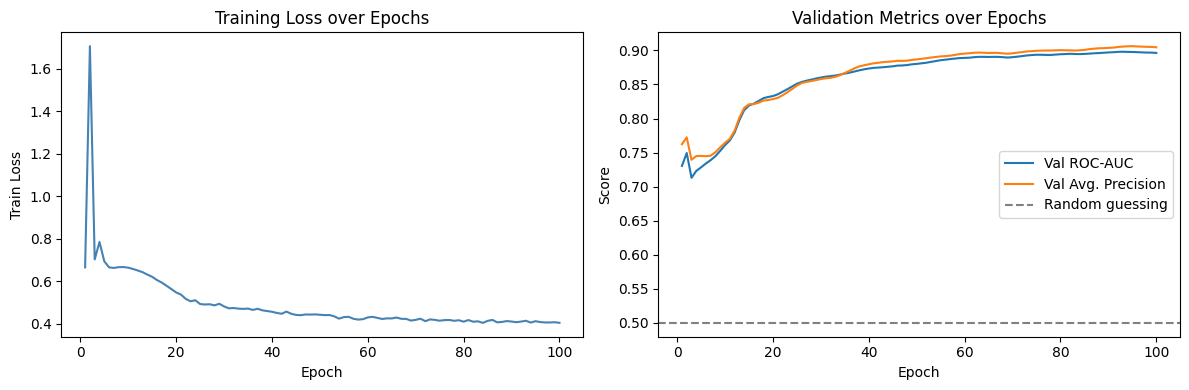

In [13]:
epochs = [h["epoch"] for h in history]
train_losses = [h["train_loss"] for h in history]
val_aucs = [h["val_auc"] for h in history]
val_aps = [h["val_ap"] for h in history]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, train_losses, color="steelblue")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Train Loss")
axes[0].set_title("Training Loss over Epochs")

axes[1].plot(epochs, val_aucs, label="Val ROC-AUC")
axes[1].plot(epochs, val_aps, label="Val Avg. Precision")
axes[1].axhline(0.5, color="gray", linestyle="--", label="Random guessing")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].set_title("Validation Metrics over Epochs")
axes[1].legend()

plt.tight_layout()
plt.show()


## 8. Final Evaluation on the Test Set

Test edges were never used for message-passing supervision or model selection above — this is the one-shot, held-out estimate of how well the model ranks real citations above fake ones.


In [14]:
test_auc, test_ap = evaluate(model, test_data)
print(f"Test ROC-AUC: {test_auc:.4f} | Test Average Precision: {test_ap:.4f}")


Test ROC-AUC: 0.9186 | Test Average Precision: 0.9231


## 9. Inference: Score Specific Pairs & Recommend New Links

Two flavors of inference for link prediction:
1. **Pairwise scoring** — given two specific papers, how likely is it they're connected?
2. **Top-k recommendation** — given one paper, which *other* papers (that it doesn't already cite) does the model think are most likely to be related? This is the same pattern real systems use for "people you may know" or "papers you may want to cite."


In [15]:
@torch.no_grad()
def score_pair(model, data, node_a, node_b):
    model.eval()
    z = model.encode(data.x, data.edge_index)
    edge_index = torch.tensor([[node_a], [node_b]], device=data.x.device)
    logit = model.decode(z, edge_index)
    return torch.sigmoid(logit).item()


# Use the full graph (all real edges) as the message-passing context for inference.
full_data = data.to(device)

# Score one held-out real test edge (should score high) vs. one random fake pair (should score low).
real_pair_idx = (test_data.edge_label == 1).nonzero()[0].item()
real_a, real_b = test_data.edge_label_index[:, real_pair_idx].tolist()
fake_pair_idx = (test_data.edge_label == 0).nonzero()[0].item()
fake_a, fake_b = test_data.edge_label_index[:, fake_pair_idx].tolist()

print(f"Held-out REAL citation  {real_a} <-> {real_b}: predicted probability = {score_pair(model, full_data, real_a, real_b):.4f}")
print(f"Random FAKE pair        {fake_a} <-> {fake_b}: predicted probability = {score_pair(model, full_data, fake_a, fake_b):.4f}")


Held-out REAL citation  306 <-> 910: predicted probability = 0.9992
Random FAKE pair        1805 <-> 309: predicted probability = 0.3688


In [16]:
@torch.no_grad()
def recommend_top_k(model, data, query_node, k=5):
    model.eval()
    z = model.encode(data.x, data.edge_index)
    scores = torch.sigmoid(z[query_node] @ z.T)   # score query node against every other node at once

    existing_neighbors = set(data.edge_index[1][data.edge_index[0] == query_node].tolist())
    existing_neighbors.add(query_node)  # exclude self-links

    scores[list(existing_neighbors)] = -1  # mask out the query node itself and its known citations
    top_k = torch.topk(scores, k).indices.tolist()
    return top_k, scores[top_k].tolist()


query_node = random.choice(range(data.num_nodes))
top_k_nodes, top_k_scores = recommend_top_k(model, full_data, query_node, k=5)

print(f"Paper #{query_node} — top {len(top_k_nodes)} recommended new citations (not already linked):")
for node, score in zip(top_k_nodes, top_k_scores):
    print(f"  Paper #{node}: predicted probability = {score:.4f}")


Paper #27 — top 5 recommended new citations (not already linked):
  Paper #436: predicted probability = 0.9493
  Paper #1655: predicted probability = 0.9291
  Paper #1131: predicted probability = 0.9284
  Paper #1894: predicted probability = 0.9214
  Paper #2117: predicted probability = 0.9211


## 10. Save the Model (optional)

In [17]:
torch.save(model.state_dict(), "gcn_link_predictor.pt")
print("Model saved to gcn_link_predictor.pt")

# To reload later:
# model = GCNLinkPredictor(in_features=dataset.num_node_features, hidden_dim=128, out_dim=64)
# model.load_state_dict(torch.load("gcn_link_predictor.pt", map_location=device))
# model.to(device)


Model saved to gcn_link_predictor.pt
